# 전처리 & 머신러닝 통합 개인과제

## Part 2. 구매 고객 특성 분석 및 시각화

### 실무 시나리오

전자상거래 기업의 CRM팀은 모든 고객에게 동일한 프로모션을 제공하면서 마케팅 비용이 증가하고 있습니다.  
이에 데이터 분석팀은 Part 1에서 정제한 고객 데이터를 활용하여 **구매율과 구매금액이 높은 고객군을 찾고, 고객의 구매 행동을 설명할 수 있는 주요 변수를 확인**하려고 합니다.

수강생은 데이터 분석 담당자로서 다음 업무를 수행합니다.

1. 고객군별 구매 특성을 비교합니다.
2. 구매 행동의 분포와 변수 간 관계를 시각화합니다.
3. 분석 결과를 바탕으로 Part 3 구매예측 모델에 사용할 Feature 후보를 정리합니다.

> 문제 1~3은 필수 문제입니다.  
> 문제 4는 추가 분석을 위한 심화 문제이며 선택적으로 수행합니다.  
> 차트 종류와 표현 방식은 정해진 하나의 답만 있는 것이 아닙니다. 분석 목적에 적절하고 제목·축·범례가 명확하면 인정합니다.

## 과제 목표

- 전처리된 데이터의 주요 구매 현황을 확인할 수 있습니다.
- 두 개 이상의 기준으로 고객 데이터를 집계하고 집단별 구매 차이를 설명할 수 있습니다.
- 분석 목적에 적합한 차트를 선택하고 기본 시각 요소를 설정할 수 있습니다.
- EDA 결과를 근거로 머신러닝 Feature 후보를 제안할 수 있습니다.

## 사용 환경 및 데이터

- Python 3.X
- pandas, numpy
- `전자상거래_고객구매_전처리완료.csv`

# 문제 1. 주요 고객군의 구매 특성 비교

## 업무 상황

CRM팀은 프로모션 대상을 정하기 위해 어떤 고객군의 구매율과 구매금액이 높은지 확인하려고 합니다.  
전체 평균만 확인하면 집단별 차이를 알기 어렵기 때문에, 고객 특성을 기준으로 구매 실적을 비교해야 합니다.

## 필수 요구사항

1. 전처리 완료 데이터를 불러오고 데이터 크기와 주요 컬럼을 확인하세요.
2. 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.
3. 회원등급, 지역, 연령대, 선호 카테고리 중 적절한 기준을 선택하여 고객군별 구매 특성을 집계하세요.
4. **두 개 이상의 기준을 함께 사용한 그룹 집계**를 1개 이상 수행하세요.
5. 집계 결과를 바탕으로 구매율 또는 평균 구매금액이 높은 고객군을 간단히 설명하세요.

## 힌트

- 고객 수, 구매 고객 수, 구매율, 평균 구매금액, 평균 방문횟수 등을 집계 지표로 활용할 수 있습니다.
- 구매율이 높더라도 고객 수가 매우 적다면 해석에 주의해야 합니다.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PATH = Path("전자상거래_고객구매_전처리완료.csv")

# TODO: 원본 데이터를 불러와 df에 저장하세요.
df = pd.read_csv(DATA_PATH)

# TODO: 데이터의 크기, 컬럼, 자료형과 기초 통계량을 확인하세요.
print(df.shape)
print(df.columns)
print(df.dtypes)
display(df.describe())

# TODO: 결측치, 중복 데이터와 주요 범주형 컬럼의 값을 확인하세요.
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.columns)

(1500, 18)
Index(['CustomerID', 'Gender', 'Age', 'Region', 'MembershipLevel',
       'VisitCount', 'AveragePurchaseAmount', 'TotalPurchaseAmount',
       'SatisfactionScore', 'LastPurchaseDate', 'CouponUsed',
       'PreferredCategory', 'SignupDate', 'Email', 'PurchaseStatus',
       'AgeGroup', 'PurchaseGrade', 'RecentPurchase'],
      dtype='str')
CustomerID                   str
Gender                       str
Age                      float64
Region                       str
MembershipLevel              str
VisitCount                 int64
AveragePurchaseAmount    float64
TotalPurchaseAmount      float64
SatisfactionScore        float64
LastPurchaseDate             str
CouponUsed                   str
PreferredCategory            str
SignupDate                   str
Email                        str
PurchaseStatus             int64
AgeGroup                     str
PurchaseGrade                str
RecentPurchase              bool
dtype: object


,Age,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,SatisfactionScore,PurchaseStatus
count,1500.000000,1500.000000,1500.000000,1.500000e+03,1500.000000,1500.000000
mean,39.413667,9.050000,120057.533333,3.888998e+05,3.662600,0.488667
std,10.672175,2.943004,51559.879750,2.604137e+05,0.746194,0.500038
min,18.000000,1.000000,5000.000000,5.000000e+03,1.700000,0.000000
25%,32.000000,7.000000,83975.000000,1.864250e+05,3.200000,0.000000
50%,39.000000,9.000000,117500.000000,3.360500e+05,3.700000,0.000000
75%,47.000000,11.000000,149750.000000,5.360250e+05,4.200000,1.000000
max,69.500000,17.000000,248412.500000,1.060425e+06,5.000000,1.000000


CustomerID                0
Gender                    0
Age                       0
Region                    0
MembershipLevel           0
VisitCount                0
AveragePurchaseAmount     0
TotalPurchaseAmount       0
SatisfactionScore         0
LastPurchaseDate          0
CouponUsed                0
PreferredCategory         0
SignupDate               15
Email                     0
PurchaseStatus            0
AgeGroup                  0
PurchaseGrade             0
RecentPurchase            0
dtype: int64
0
Index(['CustomerID', 'Gender', 'Age', 'Region', 'MembershipLevel',
       'VisitCount', 'AveragePurchaseAmount', 'TotalPurchaseAmount',
       'SatisfactionScore', 'LastPurchaseDate', 'CouponUsed',
       'PreferredCategory', 'SignupDate', 'Email', 'PurchaseStatus',
       'AgeGroup', 'PurchaseGrade', 'RecentPurchase'],
      dtype='str')


In [4]:
# TODO: 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.
print("전체 고객 수:", len(df))
print("구매 고객 수:", df["PurchaseStatus"].sum())
print("구매율:", df["PurchaseStatus"].mean())

display(df[["Age", "VisitCount", "AveragePurchaseAmount", "TotalPurchaseAmount", "SatisfactionScore"]].describe())

전체 고객 수: 1500
구매 고객 수: 733
구매율: 0.4886666666666667


,Age,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,SatisfactionScore
count,1500.000000,1500.000000,1500.000000,1.500000e+03,1500.000000
mean,39.413667,9.050000,120057.533333,3.888998e+05,3.662600
std,10.672175,2.943004,51559.879750,2.604137e+05,0.746194
min,18.000000,1.000000,5000.000000,5.000000e+03,1.700000
25%,32.000000,7.000000,83975.000000,1.864250e+05,3.200000
50%,39.000000,9.000000,117500.000000,3.360500e+05,3.700000
75%,47.000000,11.000000,149750.000000,5.360250e+05,4.200000
max,69.500000,17.000000,248412.500000,1.060425e+06,5.000000


In [5]:
# TODO: 고객 특성 한 가지를 기준으로 구매 특성을 집계하세요.
display(
    df.groupby("AgeGroup")["PurchaseStatus"].agg(
        고객수="count",
        구매고객수="sum",
        구매율="mean"
    )
)

# TODO: 두 개 이상의 기준을 함께 사용하여 그룹 집계를 수행하세요.
display(
    df.groupby(["AgeGroup", "Gender"])["PurchaseStatus"].agg(
        고객수="count",
        구매고객수="sum",
        구매율="mean"
    )
)

,고객수,구매고객수,구매율
AgeGroup,,,
10대 이하,52,20,0.384615
20대,217,110,0.506912
30대,524,258,0.492366
40대,463,214,0.462203
50대,190,106,0.557895
60대 이상,54,25,0.462963


고객수  구매고객수       구매율
AgeGroup Gender                       
10대 이하   F          1      0  0.000000
         Female    24      7  0.291667
         MALE       1      1  1.000000
         Male      21     11  0.523810
         Other      3      1  0.333333
         Unknown    1      0  0.000000
         male       1      0  0.000000
20대      F          1      1  1.000000
         FEMALE     1      1  1.000000
         Female   102     55  0.539216
         M          3      2  0.666667
         MALE       2      2  1.000000
         Male      96     41  0.427083
         Other      5      3  0.600000
         Unknown    3      2  0.666667
         female     1      1  1.000000
         male       3      2  0.666667
30대      F          7      3  0.428571
         FEMALE     5      4  0.800000
         Female   240    111  0.462500
         M          4      2  0.500000
         MALE       6      4  0.666667
         Male     229    120  0.524017
         Other     15      8  0.533333
         Unknown    7      2  0.285714
         female     3      1  0.333333
         male       8      3  0.375000
40대      F          3      1  0.333333
         FEMALE     7      4  0.571429
         Female   213     92  0.431925
         M          2      1  0.500000
         MALE       5      3  0.600000
         Male     200     96  0.480000
         Other     16     11  0.687500
         Unknown    6      2  0.333333
         female     9      4  0.444444
         male       2      0  0.000000
50대      F          1      1  1.000000
         FEMALE     1      0  0.000000
         Female    83     48  0.578313
         M          3      2  0.666667
         Male      86     47  0.546512
         Other      7      4  0.571429
         Unknown    7      2  0.285714
         female     2      2  1.000000
60대 이상   F          1      1  1.000000
         Female    26     11  0.423077
         M          1      1  1.000000
         Male      23     10  0.434783
         Other      1      1  1.000000
         Unknown    2      1  0.500000

### 문제 1 결과 정리

- 전체 구매 현황: 전체 고객 1,500명 중 구매 고객은 733명으로, **구매율은 약 48.87%**이다.
- 구매율이 높은 고객군: 연령대별로는 50대 고객군의 구매율이 약 55.79%로 가장 높았고, 20대가 약 50.69%로 뒤를 이었다.
- 평균 구매금액이 높은 고객군: 현재 제공된 결과에는 연령대별 평균 구매금액 집계가 없으므로 추가 집계가 필요하다.
- 고객 수를 함께 고려했을 때 주의할 점: 고객 수가 적은 집단은 일부 고객의 구매 여부나 구매금액에 따라 결과가 크게 달라질 수 있으므로, 구매율이나 평균 구매금액만으로 고객군의 특성을 단정하지 않고 고객 수를 함께 고려해야 한다.

# 문제 2. 구매 행동의 분포와 관계 시각화

## 업무 상황

고객군별 평균만으로는 실제 데이터가 어느 구간에 집중되어 있는지, 일부 극단값이 평균에 영향을 주는지 알기 어렵습니다.  
CRM팀이 결과를 쉽게 이해할 수 있도록 구매 행동의 분포, 고객군 간 차이, 변수 간 관계를 시각화해야 합니다.

## 필수 요구사항

1. 구매금액, 방문횟수, 만족도 등 주요 수치형 변수 중 하나 이상의 분포를 시각화하세요.
2. 회원등급, 구매 여부 등 고객 집단별 차이를 비교할 수 있는 차트를 작성하세요.
3. 두 수치형 변수의 관계를 확인할 수 있는 차트를 작성하세요.
4. 모든 차트에 분석 내용을 이해할 수 있는 제목과 축 이름을 표시하고, 필요한 경우 범례를 추가하세요.
5. 차트에서 확인한 주요 패턴을 간단히 설명하세요.

## 힌트

- 분포 확인에는 히스토그램이나 박스플롯을 사용할 수 있습니다.
- 집단 비교에는 막대그래프나 그룹별 박스플롯을 사용할 수 있습니다.
- 수치형 변수 관계에는 산점도를 사용할 수 있습니다.

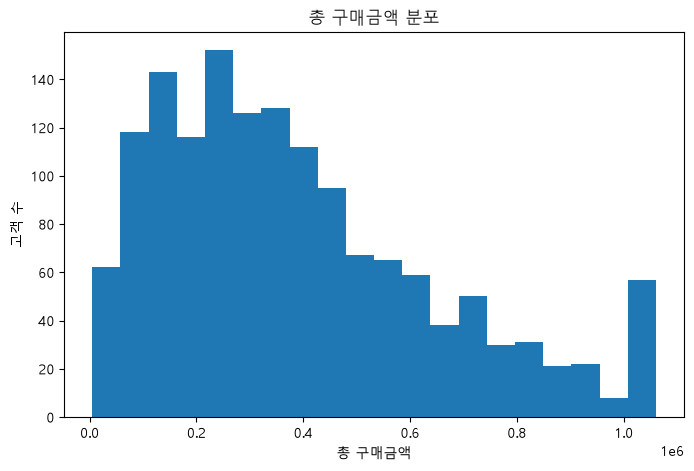

In [7]:
# TODO: 주요 수치형 변수의 분포를 시각화하세요.
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8, 5))
plt.hist(df["TotalPurchaseAmount"], bins=20)
plt.title("총 구매금액 분포")
plt.xlabel("총 구매금액")
plt.ylabel("고객 수")
plt.show()

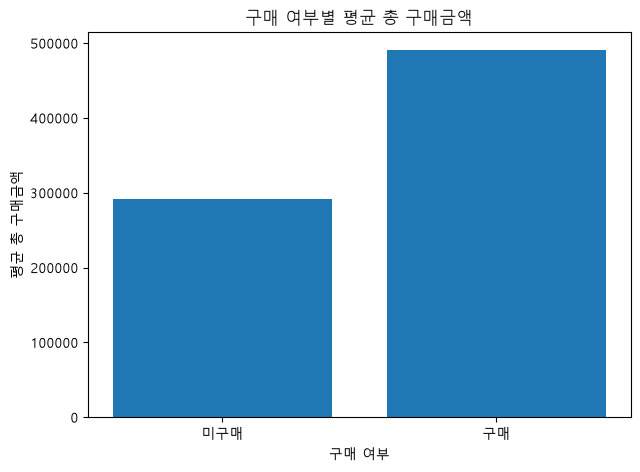

In [8]:
# TODO: 고객 집단별 구매 차이를 비교하는 차트를 작성하세요.
plt.figure(figsize=(7, 5))

purchase_group = df.groupby("PurchaseStatus")["TotalPurchaseAmount"].mean()

plt.bar(["미구매", "구매"], purchase_group.values)
plt.title("구매 여부별 평균 총 구매금액")
plt.xlabel("구매 여부")
plt.ylabel("평균 총 구매금액")
plt.show()

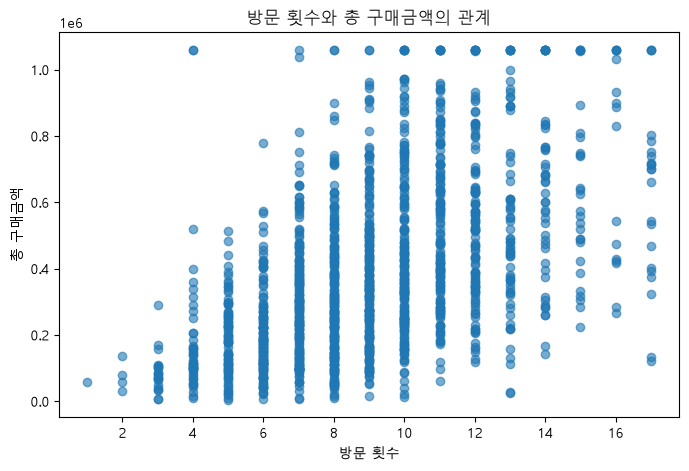

In [9]:
# TODO: 두 수치형 변수의 관계를 확인하는 차트를 작성하세요.
plt.figure(figsize=(8, 5))

plt.scatter(df["VisitCount"], df["TotalPurchaseAmount"], alpha=0.6)
plt.title("방문 횟수와 총 구매금액의 관계")
plt.xlabel("방문 횟수")
plt.ylabel("총 구매금액")
plt.show()

### 문제 2 결과 정리

- 주요 변수의 분포 특징:
- 고객 집단별 차이:
- 두 변수 사이에서 확인한 관계:
- 시각화 결과가 고객 분석에 주는 의미:


# 문제 3. 구매예측 모델링 Feature 후보 정리

## 업무 상황

Part 3에서는 고객의 구매 여부를 예측하는 머신러닝 모델을 개발합니다.  
모델에 모든 컬럼을 그대로 넣기보다, 이번 EDA에서 구매 행동과 관련성이 확인된 변수와 제외해야 할 변수를 구분해야 합니다.

## 필수 요구사항

1. 수치형 변수와 `PurchaseStatus`의 관계를 확인할 수 있는 표 또는 시각화를 작성하세요.
2. 문제 1과 문제 2의 분석 결과를 바탕으로 모델링에 사용할 Feature 후보를 정리하세요.
3. 고객 식별자처럼 일반적인 구매 패턴 학습에 적절하지 않은 컬럼을 제외 후보로 구분하세요.
4. 각 Feature 후보를 선정한 근거를 EDA 결과와 연결하여 간단히 설명하세요.

## 힌트

- 상관계수는 수치형 변수 사이의 선형 관계를 확인하는 참고 자료입니다.
- 상관계수가 낮더라도 범주형 변수나 비선형 관계를 가진 변수는 모델에 유용할 수 있습니다.
- 고객 ID와 같은 고유 식별자는 새로운 고객의 구매 패턴을 일반화하는 데 적절하지 않을 수 있습니다.

In [ ]:
# TODO: 수치형 변수와 PurchaseStatus의 관계를 확인하세요.

In [ ]:
# TODO: EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리하세요.

### 문제 3 결과 정리

#### 모델링 Feature 후보

- 수치형 Feature:
- 범주형 Feature:
- 선정 근거:

#### 제외 후보

- 제외할 컬럼:
- 제외 이유:



# (심화)문제 4. 분석 결과의 심화 해석

## 업무 상황

CRM팀은 기본 분석 결과를 실제 마케팅과 구매예측 모델에 적용하기 전에,
고객군별 결과의 활용 가능성과 해석상의 주의점, 모델링 변수 구성의 위험 요소를 추가로 확인하려고 합니다.

## 요구사항

### 4-1. 고객군 활용 방안 제안

1. 문제 1의 집계 결과를 바탕으로 우선 관리할 고객군을 한 개 이상 선정하세요.
2. 해당 고객군을 선정한 근거를 구매율, 평균 구매금액, 고객 수 등의 지표와 연결하여 작성하세요.
3. 선정한 고객군에 적용할 수 있는 마케팅 활용 방안을 한 가지 이상 제안하세요.

### 4-2. 시각화 결과 해석 시 주의점

1. 문제 2의 분포 또는 집단 비교 차트에서 확인되는 치우침, 극단값, 집단별 차이 중 하나 이상을 설명하세요.
2. 해당 결과를 해석할 때 주의해야 할 점을 작성하세요.
3. 필요하다면 기존 분석을 보완하는 추가 차트를 한 개 작성하세요.

### 4-3. 모델링 Feature 위험 요소 검토

1. 서로 비슷한 정보를 제공하여 중복 가능성이 있는 변수를 한 쌍 이상 제시하세요.
2. 예측 시점에 사용할 수 없거나 구매 결과를 직접 반영하여 데이터 누수 가능성이 있는 변수를 검토하세요.
3. 최종 Feature 구성을 수치형 변수와 범주형 변수로 나누어 정리하세요.



## 심화 문제 결과 작성

### 4-1. 고객군 활용 방안

- 우선 관리할 고객군:
- 선정 근거:
- 제안할 마케팅 활용 방안:

### 4-2. 시각화 해석 시 주의점

- 확인한 분포 또는 집단 차이:
- 해석 시 주의할 점:
- 추가로 작성한 차트와 확인 결과:

### 4-3. Feature 위험 요소

- 중복 정보 가능성이 있는 변수:
- 데이터 누수 가능성이 있는 변수:
- 최종 수치형 Feature:
- 최종 범주형 Feature:



# 제출 결과물

## 필수 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 전체 구매 현황 | 전체 고객 수, 구매 고객 수, 구매율, 주요 기초 통계량 |
| 고객군별 집계표 | 단일 기준 및 두 개 이상 기준의 그룹 집계 |
| 고객군 해석 | 구매율 또는 평균 구매금액이 높은 고객군 설명 |
| 주요 시각화 | 분포, 고객 집단 비교, 두 수치형 변수 관계 차트 |
| Feature 후보 | 모델링에 사용할 Feature와 제외 후보 및 선정 근거 |

## 심화 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 고객군 활용 방안 | 우선 관리 고객군과 마케팅 제안 |
| 시각화 해석 주의점 | 치우침·극단값·집단 차이 해석과 주의사항 |
| Feature 위험 검토 | 중복 정보와 데이터 누수 가능성 검토 |
| 최종 Feature 구성 | 수치형·범주형 Feature 구분 |

# 제출 전 체크리스트

## 필수 체크리스트

- [ ] Part 1 전처리 완료 데이터를 사용했습니다.
- [ ] 전체 구매 현황과 주요 기초 통계량을 확인했습니다.
- [ ] 두 개 이상의 기준을 사용한 그룹 집계를 수행했습니다.
- [ ] 구매 특성이 두드러진 고객군을 설명했습니다.
- [ ] 분포, 집단 비교, 변수 관계를 확인할 수 있는 시각화를 작성했습니다.
- [ ] 차트에 제목, 축 이름과 필요한 범례를 표시했습니다.
- [ ] EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리했습니다.

## 심화 체크리스트

- [ ] 우선 관리할 고객군과 마케팅 활용 방안을 제안했습니다.
- [ ] 분포 또는 집단 차이를 해석할 때의 주의점을 설명했습니다.
- [ ] 필요에 따라 추가 차트를 작성했습니다.
- [ ] 중복 정보 가능성이 있는 변수를 검토했습니다.
- [ ] 데이터 누수 가능성이 있는 변수를 검토했습니다.
- [ ] 최종 Feature를 수치형과 범주형으로 구분했습니다.
